# DPO Training

Fine-tunes GPT-4.1-nano via Direct Preference Optimization on FEVER preference pairs.
Covers: data conversion, file upload, job submission, monitoring, and label-accuracy evaluation.

Four hyperparameter configs mirror the SFT sweep (c1–c4):

| Config  | LR multiplier | Epochs | Batch size | Notes |
|---------|--------------|--------|------------|-------|
| dpo_c1  | 1.0 | 1 | 1 | baseline |
| dpo_c2  | 2.0 | 1 | 1 | higher LR |
| dpo_c3  | 1.0 | 3 | 1 | more epochs |
| dpo_c4  | 1.0 | 1 | 4 | larger batch |

In [ ]:
import os
import json
import time
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

RESOURCE_GROUP = "cis-5270-team-10"
OPENAI_API_KEY = ""

OPENAI_ENDPOINT = f"https://{RESOURCE_GROUP}.openai.azure.com"
SUBSCRIPTION_ID = ""

os.environ["AZURE_SUBSCRIPTION_ID"] = SUBSCRIPTION_ID
os.environ["AZURE_RESOURCE_GROUP"]  = "CIS-5270"
os.environ["AZURE_AOAI_ACCOUNT"]    = RESOURCE_GROUP
os.environ["AZURE_OPENAI_API_KEY"]  = OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_ENDPOINT

CREDENTIAL = DefaultAzureCredential()

openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)

BASE_MODEL = "gpt-4.1-nano-2025-04-14"

print("Connected to Azure OpenAI")

Connected to Azure OpenAI


## Step 1: Convert, Upload Training and Validation Files

Convert `dpo_data_3k.jsonl` (prompt / chosen / rejected) to Azure DPO format
(input / preferred_output / non_preferred_output), filter invalid rows, and save to `dpo_train_azure.jsonl`.
Convert `sft_val_upload.jsonl` (all 300 rows) to DPO format and save to `dpo_val_azure.jsonl`.
Upload both files for fine-tuning.

In [3]:
DPO_DATA_PATH    = "data/generated/dpo_data_3k.jsonl"
DPO_UPLOAD_PATH  = "data/generated/dpo_train_azure.jsonl"
SFT_VAL_PATH     = "data/generated/sft_val_upload.jsonl"
DPO_VAL_PATH     = "data/generated/dpo_val_azure.jsonl"

SYSTEM_PROMPT = """You are a fact-checking assistant. Given a passage and a claim, respond with the verdict followed by a one-sentence justification quoting or closely paraphrasing the passage.
Format: LABEL: justification sentence
Label must be one of: SUPPORTED, CONTRADICTED, NOT MENTIONED"""

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def save_jsonl(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

def convert_train_row(row):
    return {
        "input": {
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": row["prompt"]},
            ]
        },
        "preferred_output":     [{"role": "assistant", "content": row["chosen"]}],
        "non_preferred_output": [{"role": "assistant", "content": row["rejected"]}],
    }

# --- convert DPO training data ---
raw = load_jsonl(DPO_DATA_PATH)
converted = []
for row in raw:
    try:
        chosen   = row["chosen"].strip()
        rejected = row["rejected"].strip()
        prompt   = row["prompt"].strip()
    except Exception:
        continue
    if not chosen or not rejected or not prompt or chosen == rejected:
        continue
    converted.append(convert_train_row(row))

save_jsonl(DPO_UPLOAD_PATH, converted)
print(f"DPO train: {len(converted)} rows saved to {DPO_UPLOAD_PATH}")

# --- convert sft_val_upload.jsonl to DPO val format ---
# sft_val_upload rows are {"messages": [system, user, assistant]}
# we use the assistant message as preferred_output and an empty string as non_preferred_output
sft_val_rows = load_jsonl(SFT_VAL_PATH)
dpo_val_rows = []
for row in sft_val_rows:
    msgs = row["messages"]
    system_msg = next((m["content"] for m in msgs if m["role"] == "system"), SYSTEM_PROMPT)
    user_msg   = next((m["content"] for m in msgs if m["role"] == "user"),   "")
    asst_msg   = next((m["content"] for m in msgs if m["role"] == "assistant"), "")
    if not user_msg or not asst_msg:
        continue
    dpo_val_rows.append({
        "input": {
            "messages": [
                {"role": "system", "content": system_msg},
                {"role": "user",   "content": user_msg},
            ]
        },
        "preferred_output":     [{"role": "assistant", "content": asst_msg}],
        "non_preferred_output": [{"role": "assistant", "content": ""}],
    })

save_jsonl(DPO_VAL_PATH, dpo_val_rows)
print(f"DPO val:   {len(dpo_val_rows)} rows saved to {DPO_VAL_PATH}")

# --- upload both files ---
print("\nUploading DPO training file...")
with open(DPO_UPLOAD_PATH, "rb") as f:
    dpo_train_file = openai_client.files.create(file=f, purpose="fine-tune")
dpo_train_file_id = dpo_train_file.id
print(f"DPO training file id: {dpo_train_file_id}")

print("Uploading DPO validation file...")
with open(DPO_VAL_PATH, "rb") as f:
    dpo_val_file = openai_client.files.create(file=f, purpose="fine-tune")
dpo_val_file_id = dpo_val_file.id
print(f"DPO validation file id: {dpo_val_file_id}")

print("Waiting for file processing...")
openai_client.files.wait_for_processing(dpo_train_file_id)
openai_client.files.wait_for_processing(dpo_val_file_id)
print("Files ready!")

DPO train: 3000 rows saved to data/generated/dpo_train_azure.jsonl
DPO val:   300 rows saved to data/generated/dpo_val_azure.jsonl

Uploading DPO training file...
DPO training file id: file-a0d5eb229c1a497cb4eb88371020bd09
Uploading DPO validation file...
DPO validation file id: file-6eff6a747ed345d8a1a181c332f30933
Waiting for file processing...
Files ready!


## Step 2: Submit Fine-Tuning Jobs

Four DPO configs mirroring the SFT hyperparameter sweep.

| Config | LR multiplier | Epochs | Batch size |
|--------|--------------|--------|------------|
| dpo_c1 | 1.0 | 1 | 1 |
| dpo_c2 | 2.0 | 1 | 1 |
| dpo_c3 | 1.0 | 3 | 1 |
| dpo_c4 | 1.0 | 1 | 4 |

In [4]:
FT_CONFIGS = [
    {"name": "dpo_c1", "learning_rate_multiplier": 1.0, "n_epochs": 1, "batch_size": 1},
    {"name": "dpo_c2", "learning_rate_multiplier": 2.0, "n_epochs": 1, "batch_size": 1},
    {"name": "dpo_c3", "learning_rate_multiplier": 1.0, "n_epochs": 3, "batch_size": 1},
    {"name": "dpo_c4", "learning_rate_multiplier": 1.0, "n_epochs": 1, "batch_size": 4},
]

jobs = {}
for cfg in FT_CONFIGS:
    job = openai_client.fine_tuning.jobs.create(
        model=BASE_MODEL,
        training_file=dpo_train_file_id,
        validation_file=dpo_val_file_id,
        method={
            "type": "dpo",
            "dpo": {
                "hyperparameters": {
                    "n_epochs":                 cfg["n_epochs"],
                    "batch_size":               cfg["batch_size"],
                    "learning_rate_multiplier": cfg["learning_rate_multiplier"],
                },
            },
        },
        extra_body={"trainingType": "GlobalStandard"},
        suffix=cfg["name"],
    )
    jobs[cfg["name"]] = job.id
    print(f"{cfg['name']}: job_id={job.id}  status={job.status}")

print("\nDPO fine-tuning jobs submitted")

dpo_c1: job_id=ftjob-d5e68f9e646d4fc19433dcc4ea3c410d  status=pending
dpo_c2: job_id=ftjob-f7822c5f78544f098330958699abbe67  status=pending
dpo_c3: job_id=ftjob-fa6526367acf47cd9b113397dde4da37  status=pending
dpo_c4: job_id=ftjob-5db248d3c5eb49fab158584ae2c64247  status=pending

DPO fine-tuning jobs submitted


## Step 3: Monitor Jobs and Collect Loss Curves

In [6]:
def monitor_jobs(jobs, poll_interval=60):
    """Poll jobs until done, scraping step-level loss from events for a live progress view.
    Returns the scraped curves (noisy) AND a dict of result_file_ids for clean CSV fetching."""
    scraped = {name: [] for name in jobs}
    result_file_ids = {}
    pending = dict(jobs)
    seen_steps = {name: set() for name in jobs}

    while pending:
        for name, job_id in list(pending.items()):
            job = openai_client.fine_tuning.jobs.retrieve(job_id)

            if job.status in ("succeeded", "failed", "cancelled"):
                print(f"{name}: {job.status}  model={job.fine_tuned_model}")
                if job.result_files:
                    result_file_ids[name] = job.result_files[0]
                    print(f"  result file: {result_file_ids[name]}")
                del pending[name]
                continue

            # page through all recent events to catch every step
            events = []
            after = None
            while True:
                page = openai_client.fine_tuning.jobs.list_events(
                    job_id, limit=100, after=after
                )
                batch = list(page)
                if not batch:
                    break
                events.extend(batch)
                after = batch[-1].id
                if len(batch) < 100:
                    break

            for ev in reversed(events):
                m = re.search(r"Step\s+(\d+).*?loss[=:\s]+([0-9.]+)", ev.message, re.IGNORECASE)
                if m:
                    step = int(m.group(1))
                    if step not in seen_steps[name]:
                        seen_steps[name].add(step)
                        scraped[name].append({"step": step, "loss": float(m.group(2))})

            latest = events[0].message if events else "no events"
            n_pts = len(scraped[name])
            print(f"{name}: {job.status} | pts={n_pts} | {latest[:80]}")

        if pending:
            print(f"  waiting {poll_interval}s...\n")
            time.sleep(poll_interval)

    os.makedirs("data/results", exist_ok=True)
    scraped_path = "data/results/dpo_loss_curves.json"
    with open(scraped_path, "w") as f:
        json.dump(scraped, f, indent=2)
    print(f"\nscraped loss curves saved to {scraped_path}")
    print(f"result file IDs: {result_file_ids}")
    return scraped, result_file_ids

scraped_curves, result_file_ids = monitor_jobs(jobs)

dpo_c1: running | pts=269 | Step 2680: training loss=0.004047393798828125
dpo_c2: succeeded  model=gpt-4.1-nano-2025-04-14.ft-f7822c5f78544f098330958699abbe67-dpo_c2
  result file: file-33e707e7a5874337b6ca9bccdc711486
dpo_c3: succeeded  model=gpt-4.1-nano-2025-04-14.ft-fa6526367acf47cd9b113397dde4da37-dpo_c3
  result file: file-b4f581d5c9bd4796af42262b73c8331b
dpo_c4: succeeded  model=gpt-4.1-nano-2025-04-14.ft-5db248d3c5eb49fab158584ae2c64247-dpo_c4
  result file: file-3f4560ecb741494199af5abe16ddcdf9
  waiting 60s...

dpo_c1: running | pts=269 | Step 2680: training loss=0.004047393798828125
  waiting 60s...

dpo_c1: running | pts=269 | Step 2680: training loss=0.004047393798828125
  waiting 60s...

dpo_c1: running | pts=269 | Step 2680: training loss=0.004047393798828125
  waiting 60s...

dpo_c1: running | pts=269 | Step 2680: training loss=0.004047393798828125
  waiting 60s...

dpo_c1: running | pts=273 | Step 2720: training loss=0.0037994384765625
  waiting 60s...

dpo_c1: running

## Fine-Tuned Model IDs

Paste the model IDs reported above after jobs complete:

- dpo_c1: `gpt-4.1-nano-2025-04-14.ft-d5e68f9e646d4fc19433dcc4ea3c410d-dpo_c1`
- dpo_c2: `gpt-4.1-nano-2025-04-14.ft-f7822c5f78544f098330958699abbe67-dpo_c2`
- dpo_c3: `gpt-4.1-nano-2025-04-14.ft-fa6526367acf47cd9b113397dde4da37-dpo_c3`
- dpo_c4: `gpt-4.1-nano-2025-04-14.ft-5db248d3c5eb49fab158584ae2c64247-dpo_c4`

### Val Metrics from Result Files

Fetch the Azure result CSV (one row per training step) to get per-checkpoint val loss and token accuracy — same approach as SFT-EF-CT.

In [10]:
import csv
import io

def safe_float(s):
    try: return float(s)
    except: return None

def fetch_clean_curves(result_file_ids):
    """Download Azure result CSVs and parse into step-aligned train/val loss arrays."""
    curves = {}
    for name, fid in result_file_ids.items():
        content = openai_client.files.content(fid).read().decode("utf-8")
        rows = list(csv.DictReader(io.StringIO(content)))
        steps           = [int(r["step"]) for r in rows]
        train_loss      = [safe_float(r.get("train_loss")) for r in rows]
        valid_loss      = [safe_float(r.get("valid_loss")) for r in rows]
        full_valid_loss = [safe_float(r.get("full_valid_loss")) for r in rows]
        full_valid_acc  = [safe_float(r.get("full_valid_mean_token_accuracy")) for r in rows]
        curves[name] = {
            "steps": steps,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "full_valid_loss": full_valid_loss,
            "full_valid_acc": full_valid_acc,
        }
        print(f"{name}: {len(rows)} rows from result file {fid}")
    return curves

clean_curves = fetch_clean_curves(result_file_ids)

CLEAN_PATH = "data/results/dpo_loss_curves_clean.json"
with open(CLEAN_PATH, "w") as f:
    json.dump(clean_curves, f, indent=2)
print(f"clean curves saved to {CLEAN_PATH}")

print("\nVal Metrics Summary\n")
print(f"{'Config':<10} {'Steps':>6}  {'Final Train':>12}  {'Final Valid':>12}  {'Min Valid':>10}")
print("-" * 60)
for name, data in clean_curves.items():
    tl = [v for v in data["train_loss"] if v is not None]
    vl = [v for v in data["valid_loss"] if v is not None]
    print(f"{name:<10} {len(data['steps']):>6}  "
          f"{tl[-1]:>12.4f}  {vl[-1] if vl else float('nan'):>12.4f}  "
          f"{min(vl) if vl else float('nan'):>10.4f}")

dpo_c2: 3000 rows from result file file-33e707e7a5874337b6ca9bccdc711486
dpo_c3: 9000 rows from result file file-b4f581d5c9bd4796af42262b73c8331b
dpo_c4: 750 rows from result file file-3f4560ecb741494199af5abe16ddcdf9
dpo_c1: 3000 rows from result file file-8d684c1a102c414ab47bfe31e5383c39
clean curves saved to data/results/dpo_loss_curves_clean.json

Val Metrics Summary

Config      Steps   Final Train   Final Valid   Min Valid
------------------------------------------------------------
dpo_c2       3000        0.0000        0.0002      0.0000
dpo_c3       9000        0.0002        0.2413      0.0010
dpo_c4        750        0.0004        0.2088      0.0274
dpo_c1       3000        0.0017        0.0850      0.0029


using clean loss curves from Azure result files


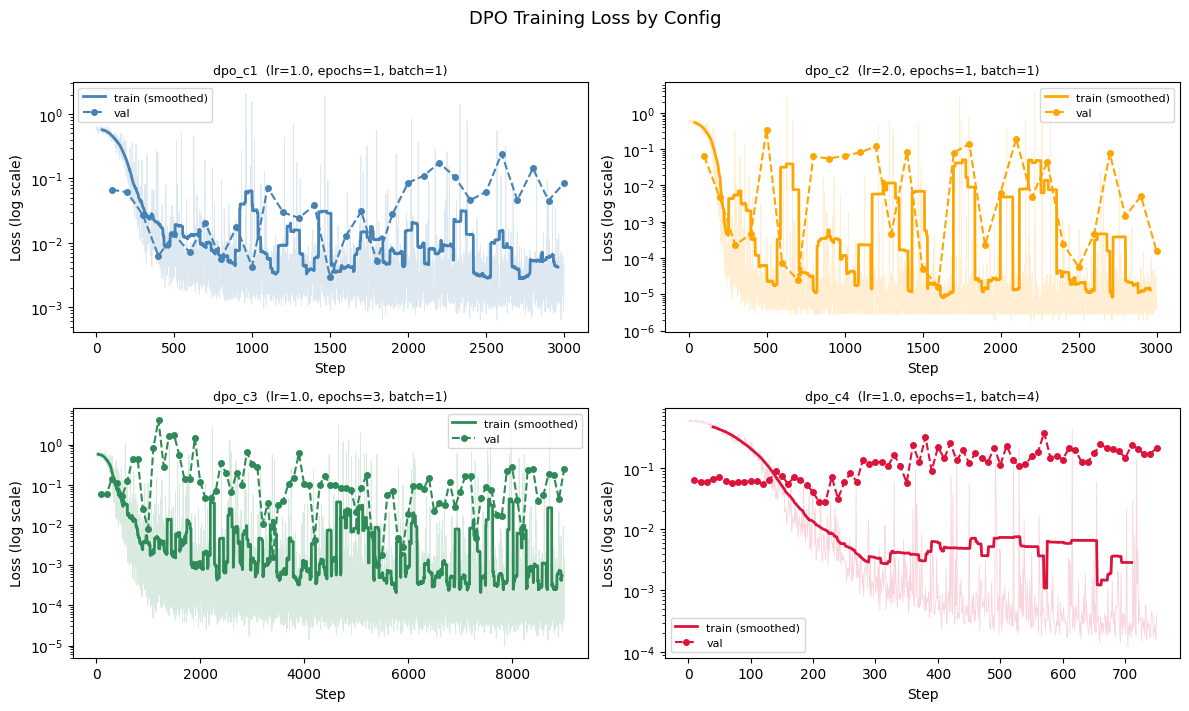

saved to data/results/dpo_loss_curves.png


In [9]:
def smooth(values, window=50):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

CLEAN_PATH   = "data/results/dpo_loss_curves_clean.json"
SCRAPED_PATH = "data/results/dpo_loss_curves.json"

if os.path.exists(CLEAN_PATH):
    with open(CLEAN_PATH) as f:
        plot_curves = json.load(f)
    print("using clean loss curves from Azure result files")
else:
    with open(SCRAPED_PATH) as f:
        scraped = json.load(f)
    plot_curves = {
        name: {"steps": [p["step"] for p in pts],
               "train_loss": [p["loss"] for p in pts],
               "valid_loss": [], "full_valid_loss": [], "full_valid_acc": []}
        for name, pts in scraped.items()
    }
    print("clean curves not yet available, using scraped (noisy)")

configs = ["dpo_c1", "dpo_c2", "dpo_c3", "dpo_c4"]
titles  = {
    "dpo_c1": "dpo_c1  (lr=1.0, epochs=1, batch=1)",
    "dpo_c2": "dpo_c2  (lr=2.0, epochs=1, batch=1)",
    "dpo_c3": "dpo_c3  (lr=1.0, epochs=3, batch=1)",
    "dpo_c4": "dpo_c4  (lr=1.0, epochs=1, batch=4)",
}
colors  = {"dpo_c1": "steelblue", "dpo_c2": "orange", "dpo_c3": "seagreen", "dpo_c4": "crimson"}
WINDOW  = 80

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, name in zip(axes, configs):
    if name not in plot_curves:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(titles[name], fontsize=9)
        continue

    data  = plot_curves[name]
    color = colors[name]

    train_pts = [(s, v) for s, v in zip(data["steps"], data["train_loss"]) if v is not None and v > 0]
    valid_pts = [(s, v) for s, v in zip(data["steps"], data["valid_loss"]) if v is not None and v > 0]
    steps_t = np.array([s for s, v in train_pts])
    loss_t  = np.array([v for s, v in train_pts])

    if len(loss_t) > WINDOW:
        smoothed = smooth(loss_t, WINDOW)
        trim = (len(steps_t) - len(smoothed)) // 2
        steps_s = steps_t[trim: trim + len(smoothed)]
        ax.semilogy(steps_t, loss_t, color=color, alpha=0.18, linewidth=0.6)
        ax.semilogy(steps_s, smoothed, color=color, linewidth=2, label="train (smoothed)")
    else:
        ax.plot(steps_t, loss_t, color=color, linewidth=1.2, label="train")

    if valid_pts:
        ax.plot([s for s, v in valid_pts], [v for s, v in valid_pts],
                color=color, linestyle="--", linewidth=1.5, marker="o", markersize=4, label="val")

    ax.set_title(titles[name], fontsize=9)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss (log scale)" if len(loss_t) > WINDOW else "Loss")
    ax.legend(fontsize=8)

plt.suptitle("DPO Training Loss by Config", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("data/results/dpo_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved to data/results/dpo_loss_curves.png")

## Step 4: Deploy Selected Models

Fill in deployment names after reviewing val metrics above.

In [23]:
DPO_DEPLOYMENTS = {
    "dpo_c1": "1-nano-2025-04-14-dpo_c1",
}

## Step 5: Evaluate on Dev Set

All configs share the same system prompt (the one used at training time).

In [24]:
VALID_LABELS = {"SUPPORTED", "CONTRADICTED", "NOT MENTIONED"}

def extract_label(text):
    for lbl in VALID_LABELS:
        if text.upper().startswith(lbl + ":"):
            return lbl
    if text.strip() in VALID_LABELS:
        return text.strip()
    for lbl in sorted(VALID_LABELS, key=len, reverse=True):
        if re.search(rf'\b{lbl}\b', text.upper()):
            return lbl
    return None

def predict_dpo(passage, claim, deployment, temperature=0.0):
    user_msg = f"Passage: {passage}\n\nClaim: {claim}"
    for attempt in range(3):
        try:
            resp = openai_client.chat.completions.create(
                model=deployment,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=temperature,
                max_tokens=150,
            )
            text = resp.choices[0].message.content.strip()
            label = extract_label(text)
            if label:
                return label, text
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  failed after 3 attempts: {e}")
    return None, None

def run_eval(cfg_name, deployment, examples, out_path):
    done_ids = set()
    results = []
    if os.path.exists(out_path):
        with open(out_path) as f:
            for line in f:
                r = json.loads(line)
                done_ids.add(r["id"])
                results.append(r)
        print(f"resuming, {len(done_ids)} already done")

    skipped = 0
    with open(out_path, "a") as out_f:
        for i, ex in enumerate(examples):
            if ex["id"] in done_ids:
                continue
            pred_label, raw = predict_dpo(ex["passage"], ex["claim"], deployment)
            if pred_label is None:
                skipped += 1
                continue
            record = {"id": ex["id"], "label": ex["label"], "pred_label": pred_label, "raw": raw}
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            results.append(record)
            if (i + 1) % 100 == 0:
                print(f"  [{i+1}/{len(examples)}] skipped={skipped}")

    print(f"done. total={len(results)} skipped={skipped}")
    return results

In [27]:
random.seed(42)

dev_data = []
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        dev_data.append(json.loads(line))

buckets = defaultdict(list)
for ex in dev_data:
    buckets[ex["label"]].append(ex)

eval_sample = []
for lbl, items in buckets.items():
    random.shuffle(items)
    eval_sample.extend(items[:400])
random.shuffle(eval_sample)

print(f"dev sample: {len(eval_sample)} examples")
print(Counter(ex["label"] for ex in eval_sample))

dev sample: 1200 examples
Counter({'CONTRADICTED': 400, 'SUPPORTED': 400, 'NOT MENTIONED': 400})


In [34]:
all_results = {}
for cfg_name, deployment in DPO_DEPLOYMENTS.items():
    print(f"Config: {cfg_name}  deployment: {deployment}")
    out_path = f"data/results/{cfg_name}_dev.jsonl"
    results = run_eval(cfg_name, deployment, eval_sample, out_path)
    all_results[cfg_name] = results
    print()

Config: dpo_c1  deployment: 1-nano-2025-04-14-dpo_c1
resuming, 854 already done
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Pl

## Results: Label Accuracy on Dev Set

In [35]:
def compute_metrics(results):
    labels = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]
    per_class = {lbl: {"correct": 0, "total": 0} for lbl in labels}
    confusion = {true: {pred: 0 for pred in labels} for true in labels}
    total_correct = 0

    for r in results:
        gt, pred = r["label"], r["pred_label"]
        per_class[gt]["total"] += 1
        if pred in labels:
            confusion[gt][pred] += 1
        if pred == gt:
            per_class[gt]["correct"] += 1
            total_correct += 1

    macro_acc = sum(
        per_class[lbl]["correct"] / per_class[lbl]["total"]
        for lbl in labels if per_class[lbl]["total"] > 0
    ) / len(labels)
    overall_acc = total_correct / len(results)

    print(f"  overall accuracy: {overall_acc:.3f}  ({total_correct}/{len(results)})")
    print(f"  macro accuracy:   {macro_acc:.3f}")
    print()
    print("  Per-class accuracy:")
    for lbl in labels:
        c = per_class[lbl]
        acc = c["correct"] / c["total"] if c["total"] else 0
        print(f"    {lbl:20s}: {acc:.3f}  ({c['correct']}/{c['total']})")
    print()
    print("  Confusion matrix (rows=true, cols=pred):")
    col_w = 14
    print(" " * 22 + "".join(f"{lbl[:col_w]:>{col_w}}" for lbl in labels))
    for true_lbl in labels:
        row = f"  {true_lbl:20s}" + "".join(
            f"{confusion[true_lbl][pred_lbl]:>{col_w}}" for pred_lbl in labels
        )
        print(row)

    return macro_acc

# reload from disk so cell is self-contained
all_results = {}
for cfg_name in DPO_DEPLOYMENTS:
    path = f"data/results/{cfg_name}_dev.jsonl"
    if os.path.exists(path):
        records = []
        with open(path) as f:
            for line in f:
                if not line.strip(): continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
        all_results[cfg_name] = records
        print(f"loaded {cfg_name}: {len(records)} records")
    else:
        print(f"missing: {path}")

print("\nDPO Dev Results\n")
best_cfg, best_acc = None, 0
for cfg_name, results in all_results.items():
    print(f"Config: {cfg_name}")
    acc = compute_metrics(results)
    if acc > best_acc:
        best_acc, best_cfg = acc, cfg_name
    print()

print(f"Best config: {best_cfg}  (macro accuracy={best_acc:.3f})")

loaded dpo_c1: 1082 records

DPO Dev Results

Config: dpo_c1
  overall accuracy: 0.946  (1024/1082)
  macro accuracy:   0.938

  Per-class accuracy:
    SUPPORTED           : 0.972  (380/391)
    CONTRADICTED        : 0.850  (250/294)
    NOT MENTIONED       : 0.992  (394/397)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      380             7             4
  CONTRADICTED                    40           250             4
  NOT MENTIONED                    2             1           394

Best config: dpo_c1  (macro accuracy=0.938)


## Qualitative Examples

Two correct and two incorrect predictions per class for the best config.

In [ ]:
best_records = {}
with open(f"data/results/{best_cfg}_dev.jsonl") as f:
    for line in f:
        if not line.strip(): continue
        r = json.loads(line)
        best_records[r["id"]] = r

dev_by_id = {}
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        ex = json.loads(line)
        dev_by_id[ex["id"]] = ex

LABELS = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]

for true_label in LABELS:
    correct   = [r for r in best_records.values() if r["label"] == true_label and r["pred_label"] == true_label][:2]
    incorrect = [r for r in best_records.values() if r["label"] == true_label and r["pred_label"] != true_label][:2]

    print(f"{'='*70}")
    print(f"TRUE LABEL: {true_label}")
    print(f"{'='*70}")

    print("\n--- Correct predictions ---")
    for r in correct:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Output  : {r['raw']}")
        print()

    print("--- Incorrect predictions ---")
    for r in incorrect:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Predicted: {r['pred_label']}  (true: {r['label']})")
        print(f"  Output  : {r['raw']}")
        print()
    print()

## Step 6: Final Test Evaluation (Best Config Only)

Run once on the held-out test set using the best config selected from dev.
Do not re-run after inspecting results.

In [ ]:
BEST_CONFIG = best_cfg
BEST_DEPLOYMENT = DPO_DEPLOYMENTS[BEST_CONFIG]

random.seed(42)
test_data = []
with open("data/joined/fever_test_joined.jsonl") as f:
    for line in f:
        test_data.append(json.loads(line))

test_buckets = defaultdict(list)
for ex in test_data:
    test_buckets[ex["label"]].append(ex)

test_sample = []
for lbl, items in sorted(test_buckets.items()):
    random.shuffle(items)
    test_sample.extend(items[:334])  # ~1000 total, stratified
random.shuffle(test_sample)

print(f"test sample: {len(test_sample)} examples")
print(Counter(ex["label"] for ex in test_sample))

print(f"\nRunning final test eval: {BEST_CONFIG} ({BEST_DEPLOYMENT})")
test_results = run_eval(
    BEST_CONFIG, BEST_DEPLOYMENT, test_sample,
    f"data/results/dpo_{BEST_CONFIG}_test.jsonl"
)

print(f"\nFinal Test Result: {BEST_CONFIG}")
compute_metrics(test_results)